In [1]:
from datasets import load_dataset

In [2]:
ds = load_dataset("tuetschek/e2e_nlg")

e2e_nlg.py:   0%|          | 0.00/3.60k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.73k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/42061 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4672 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4693 [00:00<?, ? examples/s]

In [10]:
import json
print(json.dumps(ds["train"][0], indent=2))

{
  "meaning_representation": "name[The Vaults], eatType[pub], priceRange[more than \u00a330], customer rating[5 out of 5], near[Caf\u00e9 Adriatic]",
  "human_reference": "The Vaults pub near Caf\u00e9 Adriatic has a 5 star rating.  Prices start at \u00a330."
}


In [18]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

In [20]:
enc._special_tokens

{'<|endoftext|>': 50256}

In [27]:
to_encode_text = "xfdsv<|endoftext|>dcdcs"
enc.encode_ordinary(to_encode_text)

[26152, 9310, 85, 27, 91, 437, 1659, 5239, 91, 29, 67, 10210, 6359]

In [25]:
enc._special_tokens

{'<|endoftext|>': 50256}

In [28]:
enc.eot_token

50256

In [35]:
import torch
import torch.nn as nn

# Let's use small numbers for clarity
num_movies = 4
embedding_dim = 3
batch_size = 2

# Approach 1: Dual Embeddings
class DualEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.movie_embeddings = nn.Embedding(num_movies, embedding_dim)
        self.context_embeddings = nn.Embedding(num_movies, embedding_dim)
    
    def forward(self, target_movie, context_movie):
        target_emb = self.movie_embeddings(target_movie)
        context_emb = self.context_embeddings(context_movie)
        return torch.sum(target_emb * context_emb, dim=1)

# Approach 2: Single Embedding with Projection
class SingleEmbeddingWithProjection(nn.Module):
    def __init__(self):
        super().__init__()
        self.movie_embeddings = nn.Embedding(num_movies, embedding_dim)
        self.output_layer = nn.Linear(embedding_dim, num_movies, bias=False)
    
    def forward(self, target_movie):
        target_emb = self.movie_embeddings(target_movie)
        return self.output_layer(target_emb)

# Let's demonstrate they're equivalent:
dual_model = DualEmbedding()
single_model = SingleEmbeddingWithProjection()

# Now, let's make their weights identical for comparison
with torch.no_grad():
    # Copy target embeddings
    single_model.movie_embeddings.weight.data = dual_model.movie_embeddings.weight.data.clone()
    # Copy context embeddings to output layer weights
    single_model.output_layer.weight.data = dual_model.context_embeddings.weight.data.clone()

# Test data
target_movies = torch.tensor([0, 1])  # Batch of 2 target movies
context_movie = 2  # We'll check similarity with movie ID 2

# Compute using dual embedding
dual_output = dual_model(target_movies, torch.tensor([context_movie, context_movie]))

# Compute using single embedding with projection
single_output = single_model(target_movies)[:, context_movie]

print("Dual embedding output:", dual_output)
print("Single embedding output:", single_output)
print("Are they equal?", torch.allclose(dual_output, single_output))

# We can also show that single_model computes similarities with ALL context movies at once
all_similarities = single_model(target_movies)
print("\nSimilarities with all possible context movies:")
print(all_similarities)

Dual embedding output: tensor([-0.7636, -0.8814], grad_fn=<SumBackward1>)
Single embedding output: tensor([-0.7636, -0.8814], grad_fn=<SelectBackward0>)
Are they equal? True

Similarities with all possible context movies:
tensor([[-1.9588, -1.5965, -0.7636,  0.5605],
        [-3.3449, -2.0488, -0.8814,  0.7179]], grad_fn=<MmBackward0>)


In [36]:
single_model = SingleEmbeddingWithProjection()
single_model.output_layer.weight.data.shape

torch.Size([4, 3])

In [37]:
dual_output

tensor([-0.7636, -0.8814], grad_fn=<SumBackward1>)

In [38]:
single_output

tensor([-0.7636, -0.8814], grad_fn=<SelectBackward0>)

In [ ]:
!pip 

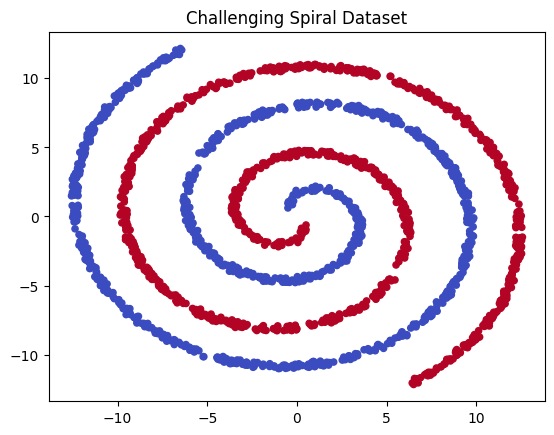

In [51]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Generate a challenging spiral dataset
def generate_spiral_data(n_points, noise=0.2):
    n = np.sqrt(np.random.rand(n_points, 1)) * 780 * (2 * np.pi) / 360
    d1x = -np.cos(n) * n + np.random.rand(n_points, 1) * noise
    d1y = np.sin(n) * n + np.random.rand(n_points, 1) * noise
    X = np.vstack((np.hstack((d1x, d1y)), np.hstack((-d1x, -d1y))))
    y = np.hstack((np.zeros(n_points), np.ones(n_points)))
    return X, y

# Create spiral data
X, y = generate_spiral_data(n_points=1000, noise=0.4)

# Convert to PyTorch tensors
X_train = torch.tensor(X, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.long)

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20)
plt.title("Challenging Spiral Dataset")
plt.show()


In [57]:
import torch.nn as nn

# Teacher Model (Higher VC Dimension)
class TeacherNN(nn.Module):
    def __init__(self):
        super(TeacherNN, self).__init__()
        self.fc1 = nn.Linear(2, 50)  # Larger hidden layer
        self.fc2 = nn.Linear(50, 50)
        self.fc3 = nn.Linear(50, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Student Model (Lower VC Dimension)
class StudentNN(nn.Module):
    def __init__(self):
        super(StudentNN, self).__init__()
        self.fc1 = nn.Linear(2, 10)  # Smaller hidden layer
        self.fc2 = nn.Linear(10, 10)  # Smaller hidden layer
        self.fc3 = nn.Linear(10, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [62]:
teacher_model = TeacherNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(teacher_model.parameters(), lr=0.01)

# Train the teacher model
for epoch in range(300):
    optimizer.zero_grad()
    outputs = teacher_model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

print("Teacher model training complete.")


Teacher model training complete.


In [63]:
student_hard_model = StudentNN()
optimizer_hard = torch.optim.Adam(student_hard_model.parameters(), lr=0.01)

# Train the student on hard labels
for epoch in range(300):
    optimizer_hard.zero_grad()
    outputs = student_hard_model(X_train)
    loss = criterion(outputs, y_train)  # Hard labels
    loss.backward()
    optimizer_hard.step()

print("Student (hard labels) training complete.")


Student (hard labels) training complete.


In [66]:
student_soft_model = StudentNN()
optimizer_soft = torch.optim.Adam(student_soft_model.parameters(), lr=0.01)

# Student Model (Knowledge Distillation with Combined Loss)
alpha = 0.5  # Weight for distillation loss
temperature = 5.0
distillation_loss = nn.KLDivLoss(reduction="batchmean")
hard_label_loss = nn.CrossEntropyLoss()

for epoch in range(300):
    optimizer_soft.zero_grad()
    
    # Teacher predictions (soft labels)
    with torch.no_grad():
        teacher_logits = teacher_model(X_train)
        teacher_soft_labels = nn.functional.softmax(teacher_logits / temperature, dim=1)
    
    # Student predictions
    student_logits = student_soft_model(X_train)
    student_soft_preds = nn.functional.log_softmax(student_logits / temperature, dim=1)
    
    # Compute distillation loss and hard label loss
    loss_distillation = distillation_loss(student_soft_preds, teacher_soft_labels)
    loss_hard = hard_label_loss(student_logits, y_train)
    loss = alpha * loss_distillation + (1 - alpha) * loss_hard  # Combined loss
    
    loss.backward()
    optimizer_soft.step()

print("Student (knowledge distillation with combined loss) training complete.")


Student (knowledge distillation with combined loss) training complete.


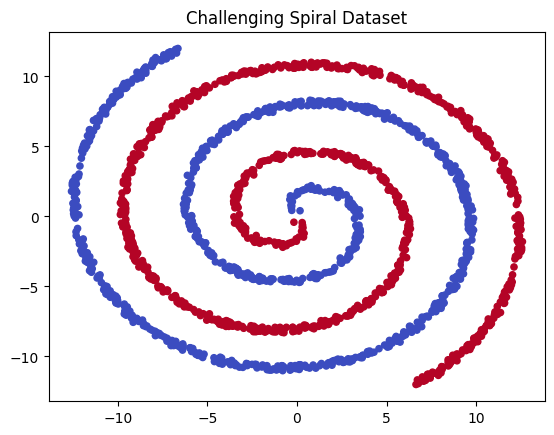

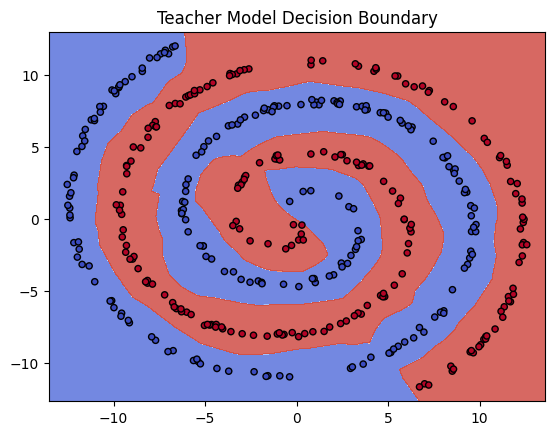

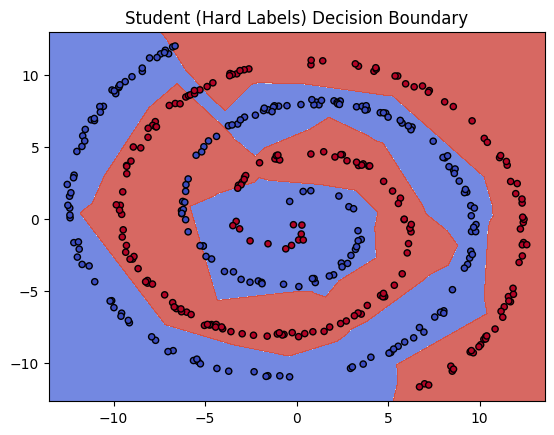

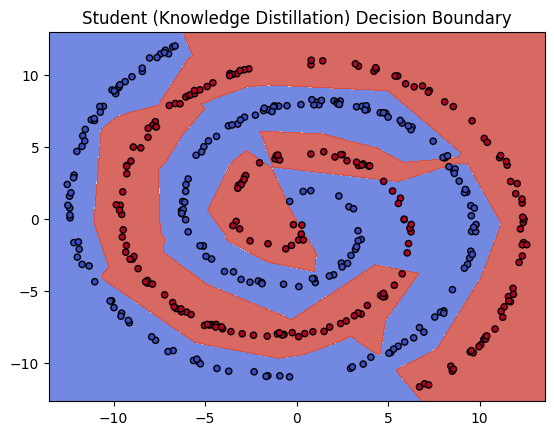

In [69]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Generate a challenging spiral dataset
def generate_spiral_data(n_points, noise=0.2):
    n = np.sqrt(np.random.rand(n_points, 1)) * 780 * (2 * np.pi) / 360
    d1x = -np.cos(n) * n + np.random.rand(n_points, 1) * noise
    d1y = np.sin(n) * n + np.random.rand(n_points, 1) * noise
    X = np.vstack((np.hstack((d1x, d1y)), np.hstack((-d1x, -d1y))))
    y = np.hstack((np.zeros(n_points), np.ones(n_points)))
    return X, y

# Create spiral data
X, y = generate_spiral_data(n_points=1000, noise=0.4)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20)
plt.title("Challenging Spiral Dataset")
plt.show()

# Define Teacher and Student Models
class TeacherNN(nn.Module):
    def __init__(self):
        super(TeacherNN, self).__init__()
        self.fc1 = nn.Linear(2, 50)
        self.fc2 = nn.Linear(50, 50)
        self.fc3 = nn.Linear(50, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class StudentNN(nn.Module):
    def __init__(self):
        super(StudentNN, self).__init__()
        self.fc1 = nn.Linear(2, 10)
        self.fc2 = nn.Linear(10, 10)
        self.fc3 = nn.Linear(10, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Train Teacher Model
teacher_model = TeacherNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(teacher_model.parameters(), lr=0.01)

for epoch in range(300):
    optimizer.zero_grad()
    outputs = teacher_model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

# Train Student Model (Hard Labels)
student_hard_model = StudentNN()
optimizer_hard = optim.Adam(student_hard_model.parameters(), lr=0.01)

for epoch in range(300):
    optimizer_hard.zero_grad()
    outputs = student_hard_model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer_hard.step()

# Train Student Model (Knowledge Distillation)
student_soft_model = StudentNN()
optimizer_soft = optim.Adam(student_soft_model.parameters(), lr=0.01)
temperature = 5.0
distillation_loss = nn.KLDivLoss(reduction="batchmean")

for epoch in range(300):
    optimizer_soft.zero_grad()
    with torch.no_grad():
        teacher_logits = teacher_model(X_train)
        teacher_soft_labels = nn.functional.softmax(teacher_logits / temperature, dim=1)
    student_logits = student_soft_model(X_train)
    student_soft_preds = nn.functional.log_softmax(student_logits / temperature, dim=1)
    loss_distillation = distillation_loss(student_soft_preds, teacher_soft_labels)
    loss_distillation.backward()
    optimizer_soft.step()

# Plot Decision Boundaries
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = model(grid)
        Z = torch.argmax(Z, dim=1).numpy()
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k', s=20)
    plt.title(title)
    plt.show()

# Plot on test set
plot_decision_boundary(teacher_model, X_test.numpy(), y_test.numpy(), "Teacher Model Decision Boundary")
plot_decision_boundary(student_hard_model, X_test.numpy(), y_test.numpy(), "Student (Hard Labels) Decision Boundary")
plot_decision_boundary(student_soft_model, X_test.numpy(), y_test.numpy(), "Student (Knowledge Distillation) Decision Boundary")


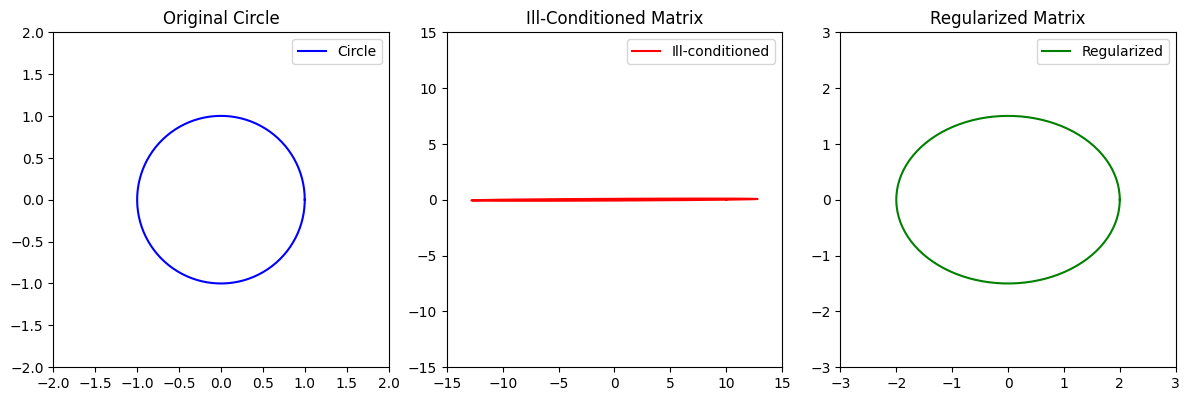

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate points on a unit circle
num_points = 200
angles = np.linspace(0, 2*np.pi, num_points)
circle = np.column_stack((np.cos(angles), np.sin(angles)))  # shape: (200, 2)

# 2. Define an ill-conditioned 2x2 matrix
#    Large ratio of largest singular value to smallest singular value
W_ill = np.array([[10, 8],
                  [ 0, 0.1]])  # Just an example

# 3. Define a "regularized" version of W_ill
#    This matrix is closer to orthogonal, so it doesn’t stretch/squash so violently
W_reg = np.array([[2, 0],
                  [0,  1.5]])  # Less extreme stretching

# 4. Transform the circle with each matrix
ellipse_ill = circle @ W_ill.T
ellipse_reg = circle @ W_reg.T

# 5. Plot the original circle + each transformed shape
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original circle
axes[0].plot(circle[:, 0], circle[:, 1], 'b', label='Circle')
axes[0].set_title("Original Circle")
axes[0].set_aspect('equal', 'box')
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-2, 2)
axes[0].legend()

# Ill-conditioned transform
axes[1].plot(ellipse_ill[:, 0], ellipse_ill[:, 1], 'r', label='Ill-conditioned')
axes[1].set_title("Ill-Conditioned Matrix")
axes[1].set_aspect('equal', 'box')
axes[1].set_xlim(-15, 15)
axes[1].set_ylim(-15, 15)
axes[1].legend()

# Regularized transform
axes[2].plot(ellipse_reg[:, 0], ellipse_reg[:, 1], 'g', label='Regularized')
axes[2].set_title("Regularized Matrix")
axes[2].set_aspect('equal', 'box')
axes[2].set_xlim(-3, 3)
axes[2].set_ylim(-3, 3)
axes[2].legend()

plt.tight_layout()
plt.show()


In [72]:
import re
# Test cases
test_cases = [
    "hello [INT-0], [INT-1]",              # → "hello"
    "hello [INT-0], world",                # → "hello, world"
    "[INT-0], [INT-1], [INT-2]",          # → ""
    "start [INT-0], [INT-1] middle",       # → "start middle"
    "[INT-0], [INT-1], and [INT-2]",      # → "and"
    "Mix of [INT-0], [TICKET-0], [EXT-0]", # → "Mix of"
    "Multiple [INT-0], [INT-1], spaces",   # → "Multiple spaces"
    "[INT-0], [INT-1].",                  # → "."
    "No refs here",                        # → "No refs here"
    "[INT-0][INT-1][INT-2]",              # → ""
    "Hello [INT-0], there [INT-1]!",      # → "Hello there!"
]

def simulate_process_references(text):
    # Simplified simulation of the reference processing
    # First, handle commas between references
    text = re.sub(r'\[(?:INT|TICKET|EXT)-\d+](?:\s*,\s*(?=\[))', '', text)
    # Then handle remaining references
    text = re.sub(r'\[(?:INT|TICKET|EXT)-\d+]', '', text)
    # Final cleanup of any stray commas before remaining references or at end
    text = re.sub(r'\s*,\s*(?=\[|$)', '', text)
    return text

# Run tests
for test in test_cases:
    result = simulate_process_references(test)
    print(f"Input:  {test}")
    print(f"Output: {result}")
    print("-" * 50)

Input:  hello [INT-0], [INT-1]
Output: hello 
--------------------------------------------------
Input:  hello [INT-0], world
Output: hello , world
--------------------------------------------------
Input:  [INT-0], [INT-1], [INT-2]
Output: 
--------------------------------------------------
Input:  start [INT-0], [INT-1] middle
Output: start  middle
--------------------------------------------------
Input:  [INT-0], [INT-1], and [INT-2]
Output: , and 
--------------------------------------------------
Input:  Mix of [INT-0], [TICKET-0], [EXT-0]
Output: Mix of 
--------------------------------------------------
Input:  Multiple [INT-0], [INT-1], spaces
Output: Multiple , spaces
--------------------------------------------------
Input:  [INT-0], [INT-1].
Output: .
--------------------------------------------------
Input:  No refs here
Output: No refs here
--------------------------------------------------
Input:  [INT-0][INT-1][INT-2]
Output: 
-------------------------------------------